# ICS 2405: Knowledge-Based Systmes
## more classification models:


> ##### CONTEXT:  
 > this covers a few more classification methods such as:   
> - random forest
> - support vector machines,
> - decision trees,
> - logistic regression and
> - discriminant analysis...

In [74]:
# setup
from mlwpy import *
%matplotlib inline

iris = datasets.load_iris()

# standard iris dataset
tts = skms.train_test_split(iris.data, iris.target, 
                            test_size=.33, random_state=21)
(iris_train_ftrs, iris_test_ftrs, 
 iris_train_tgt,  iris_test_tgt) = tts

# one-class variation
useclass = 1
tts_1c = skms.train_test_split(iris.data, iris.target==useclass, 
                               test_size=.33, random_state = 21)
(iris_1c_train_ftrs, iris_1c_test_ftrs, 
 iris_1c_train_tgt,  iris_1c_test_tgt) = tts_1c

### 1- decision trees:

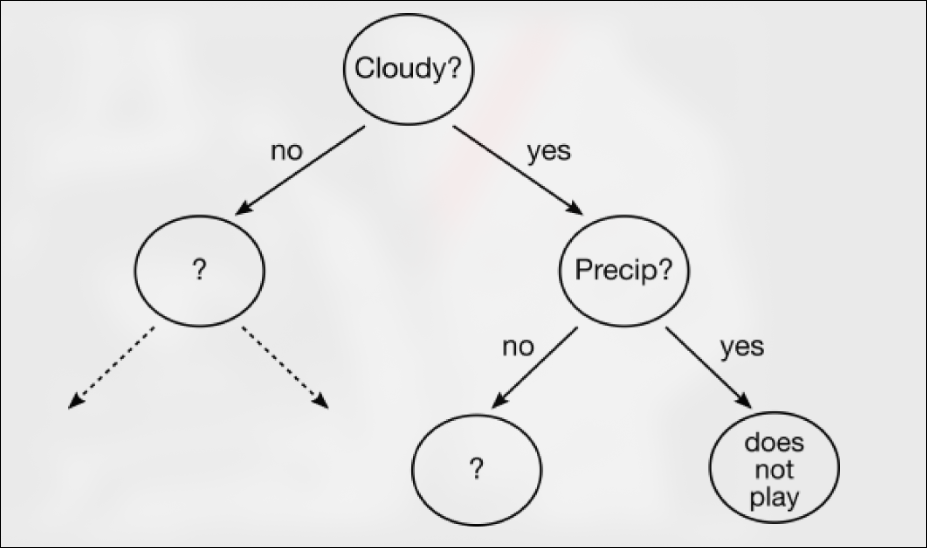

### decision tree:

#### **core concept**
- decision trees partition feature space using **axis-aligned splits** (threshold questions).
- predictions are made by following splits to a **leaf node** containing a constant prediction.

#### **overfitting:**
- **overfitting risk**: trees can memorize training data (e.g., using unique IDs like day numbers), creating a lookup table that doesn't generalize.
- 
- **causes of conflicting/mixed leaves**:
  1. Inherent randomness in outcomes.
  2. Unmeasured relevant features.
  3. Measurement errors.
- **vulnerability**: Trees have **high capacity & low bias**, making them prone to overfitting.

#### **preventing overfitting (bias-variance tradeoff)**
1. **limit tree depth** (`max_depth`).
2. **set minimum samples per leaf**.
3. **limit features considered for splits**.

#### **(building algorithm) tree-building algorithms** 
> `ID3`, `C4.5`, `CART`

**steps**:
1. evaluate all possible feature splits; choose the "best."
2. add a node representing that split.
3. for each resulting data subset:
   - if targets are sufficiently similar → create a leaf (predict).
   - otherwise, repeat from step 1.

**"best" split criteria**: based on purity (e.g., Gini index – 0.0 = perfectly pure single class).

#### **interpretation & geometry**
- boundaries are **blocky, rectangular regions** (like overlapping cards).
- model: `target = Σ (c_R * I(example in region R))` – a weighted sum over partitions.

#### **`scikit-learn` notes**
- use `tree.DecisionTreeClassifier()`.
- visualize with `export_graphviz` (requires `pydotplus` or `dot` program).
- **sanity check**: increasing `max_depth` increases model complexity (risk of overfitting).

---------------------------
Here’s how a decision tree classifier (DTC) breaks down the iris data when it only considers the first two features (sepal length and sepal width)

### decision:
the most *basic*, **baseline systems** help us decide **if we need a complicated system** and **if that system is better than
something primitive**.

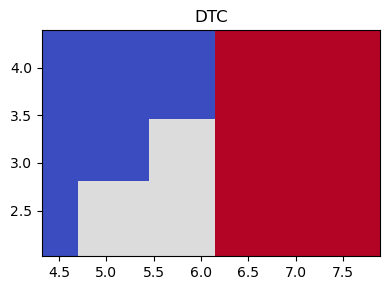

In [76]:
tree_classifiers = {'DTC' : tree.DecisionTreeClassifier(max_depth=3)}

fig, ax = plt.subplots(1,1,figsize=(4,3))
for name, mod in tree_classifiers.items():
    # plot_boundary only uses specified columns
    # [0,1] [sepal len/width] to predict and graph.  
    plot_boundary(ax, iris.data, iris.target, mod, [0,1])
    ax.set_title(name)
plt.tight_layout()

the red region (on the right) is setosa. The blue (top left) and gray (lower center) are
the two v classes. Note that the boundaries are all made with lines that are parallel to the x
or y axes.   
also, `max_depth=3` argument to the DT constructor; `max_depth` is simply the maximum number of
questions I can ask of any example before I classify it

breaking up the whole space creates a partition. we predict the class of an example based
on the color of the region the example falls into. Mathematically, we can write

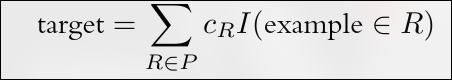

#### context foer the equation:
it is a `dot` product. `R` is a region of our graph; P is the group of all of the
regions. summing over all of the R ∈ P means that we add up some values over the
whole graph. cR is the predicted class for the region R: for example, one of the types of
`irises`. `I` is an indicator function which gives us a value of one if an example is in R and zero
otherwise. taken together, `cR` and `I`(example ∈ R) give us cR when an example is in R
and give us zero everywhere else. together, these pieces look like `∑ cRI` which is exactly
a `convoluted dot` product.

### wraps: tree buildng algortihm:
> NOTE:
> 
algorithms use either:
1. entropy or
2. informationn game

for picking attributes for the root node and the child nodes.

### decision tree with scoring:

In [77]:
dtc = tree.DecisionTreeClassifier()
skms.cross_val_score(dtc, 
                     iris.data, iris.target, 
                     cv=3, scoring='accuracy')

array([0.98, 0.94, 0.98])

In [78]:
iris_1c_tree = (tree.DecisionTreeClassifier()
                    .fit(iris_1c_train_ftrs, iris_1c_train_tgt))

In [79]:
# get pydotplus for your gnu/linux system
import pydotplus 
dot_data = tree.export_graphviz(iris_1c_tree, out_file=None) 
graph = pydotplus.graph_from_dot_data(dot_data)
graph.write_png("outputs/iris_1c.png")
Image("outputs/iris_1c.png", width=75, height=75)

ModuleNotFoundError: No module named 'pydotplus'

In [80]:
iris_tree = (tree.DecisionTreeClassifier()
                 .fit(iris_train_ftrs, iris_train_tgt))

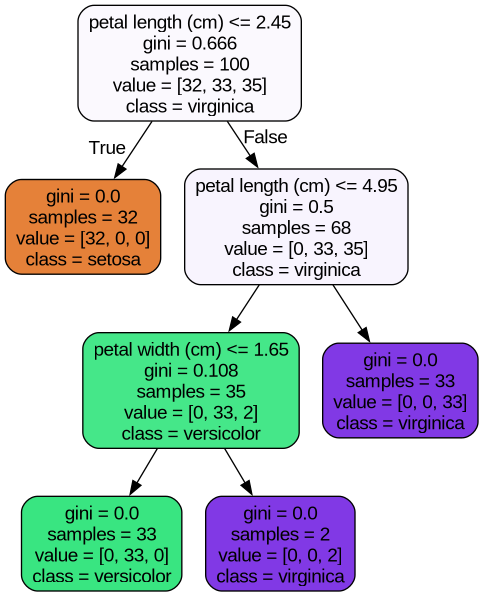

In [84]:
# no added lib. to produce .dot file
with open("outputs/iris.dot", 'w') as f:
    dot_data = tree.export_graphviz(iris_tree, out_file=f, 
                                    feature_names=iris.feature_names,  
                                    class_names=iris.target_names,  
                                    filled=True, rounded=True)

# the following '!' lines are "shell" commands
# uses the 'dot' program to convert to dot -> png
!dot -Tpng outputs/iris.dot -o outputs/iris.png
!rm outputs/iris.dot

Image("outputs/iris.png", width=960, height=140)

### what happens with increasing `depth` in a decision tree?
Remember, even at a `max_depth=2`, we’ll have three splits: one split for the root
node and one split at each of the two children. we expect to see these three splits as three
cuts across our feature space.  
the default setting, `max_depth=None`, implies not constraining the depth at all, as if `max_depth = ∞` 

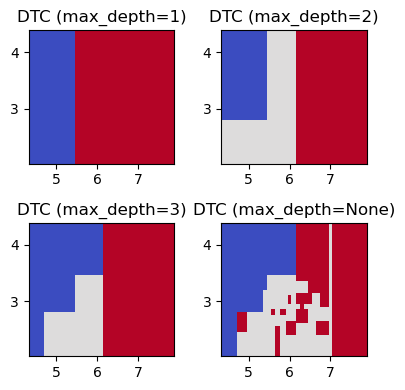

In [85]:
fig, axes = plt.subplots(2,2,figsize=(4,4))

depths = [1, 2, 3, None]
for depth, ax in zip(depths, axes.flat):
    dtc_model = tree.DecisionTreeClassifier(max_depth=depth)
    # plot_boundary only uses specified columns [0,1]
    # so we are only predicting with sepal length and width
    plot_boundary(ax, iris.data, iris.target, dtc_model, [0,1])
    ax.set_title("DTC (max_depth={})".format(dtc_model.max_depth))

plt.tight_layout()

### 2 - support vector machines:

#### **context:**
- finds the **maximum margin separator** — a line that maximizes the distance between classes.
- **support vectors**: the data points closest to the boundary that “support” the margin; only these points are needed to define the separator.
- **goal**: balance **maximizing the margin** and **minimizing classification errors**.

#### **features & advantages**
1. **sparsity**: only stores support vectors (not all data), *unlike k-NN*.
2. **simple boundary**: linear separator (can be extended to complex boundaries using kernels — see SVMs).
3. **good generalization**: large margin principle helps performance on unseen data.
4. **optimal solution**: the optimization finds the best possible separator under the constraints.

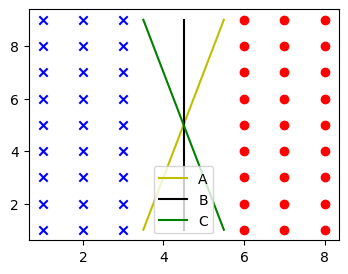

In [86]:
fig, ax = plt.subplots(1,1,figsize=(4,3))

# fancy way to get cross-product of points
left  = np.mgrid[1:4.0, 1:10].reshape(2, -1).T
right = np.mgrid[6:9.0, 1:10].reshape(2, -1).T

# data points
ax.scatter(left[:,0] , left[:,1] , c='b', marker='x')
ax.scatter(right[:,0], right[:,1], c='r', marker='o')

# separating lines
ax.plot([3.5, 5.5], [1,9], 'y', label='A')
ax.plot([4.5, 4.5], [1,9], 'k', label='B')
ax.plot([3.5, 5.5], [9,1], 'g', label='C')
ax.legend(loc='lower center');

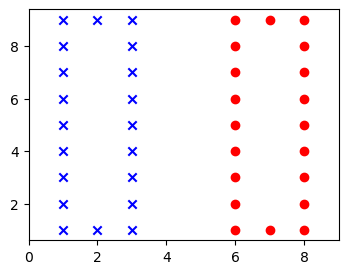

In [87]:
fig, ax = plt.subplots(1,1,figsize=(4,3))

# fancy way to get cross-product of points
left  = np.mgrid[1:4:2, 1:10].reshape(2, -1).T
right = np.mgrid[6:9:2, 1:10].reshape(2, -1).T

ax.scatter(left[:,0] , left[:,1] , c='b', marker='x')
ax.scatter([2,2], [1,9], c='b', marker='x')
ax.scatter(right[:,0], right[:,1], c='r', marker='o')
ax.scatter([7,7], [1,9], c='r', marker='o')
ax.set_xlim(0,9);

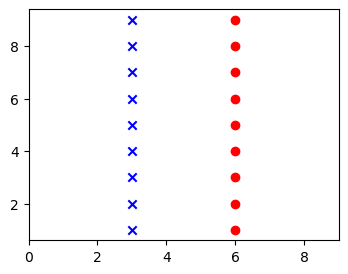

In [88]:
fig, ax = plt.subplots(1,1,figsize=(4,3))

left  = np.mgrid[3:4, 1:10].reshape(2, -1).T
right = np.mgrid[6:7, 1:10].reshape(2, -1).T

ax.scatter(left[:,0] , left[:,1] , c='b', marker='x')
ax.scatter(right[:,0], right[:,1], c='r', marker='o')
ax.set_xlim(0,9);

##### explanation text:

### performing svcs

- **multiclass**: uses **one-vs-rest (OvR)** by default.
- **four of them**:
  1. `LinearSVC`
  2. `SVC(kernel='linear')`
  3. `SVC(kernel='poly', degree=1)` (linear in disguise)
  4. `NuSVC(kernel='linear')`  
- > NOTE: these can give slightly different results due to mathematical/implementation differences.

#### running SVCs
> `SVC` and `NuSVC`

In [89]:
sv_classifiers = {"SVC(Linear)"   : svm.SVC(kernel='linear'),
                  "NuSVC(Linear)" : svm.NuSVC(kernel='linear', nu=.9)} 

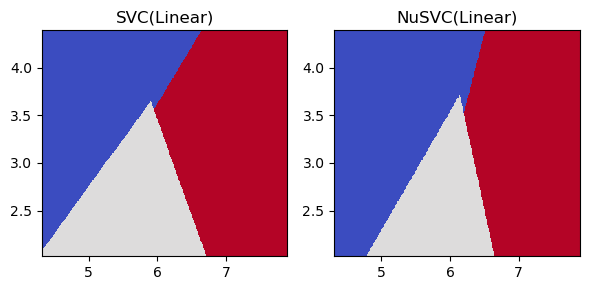

In [90]:
fig, axes = plt.subplots(1,2,figsize=(6,3))
for (name, mod), ax in zip(sv_classifiers.items(), axes.flat):
    plot_boundary(ax, iris.data, iris.target, mod, [0,1])
    ax.set_title(name)
plt.tight_layout()

#### parameters for SVCs
- **`C` (in `SVC`)**: controls trade-off between margin size and classification errors.
  - **small C**: prioritizes **large margin** (may misclassify more training points) → higher bias, lower variance.
  - **LARGE C**: prioritizes **correct classification** (smaller margin, risk of overfitting) → lower bias, higher variance.
- **`nu` (in `NuSVC`)**: more interpretable — sets an **upper bound on the fraction of margin errors** and a **lower bound on support vectors**.
  - range: 0 to 1 (percentage).
  - larger `nu` ≈ smaller `C` (allows more errors, larger margin).
- **relationship**: larger `nu` ≈ smaller `C` (similar effect, but scales differ).

In [91]:
def do_linear_svc_separators(svc_maker, pname, params, ax):
    'create svc(params) and draw seperation boundary'
    xys = (np.linspace(2,8,100),
           np.linspace(2,8,100))

    for p in params:
        kwargs = {pname:p, 'kernel':'linear'}
        svc = svc_maker(**kwargs).fit(ftrs, tgt)
        # plot_separator is in mlwpy.py
        plot_separator(svc, *xys, 
                       '{}={:g}'.format(pname, p), ax=ax)

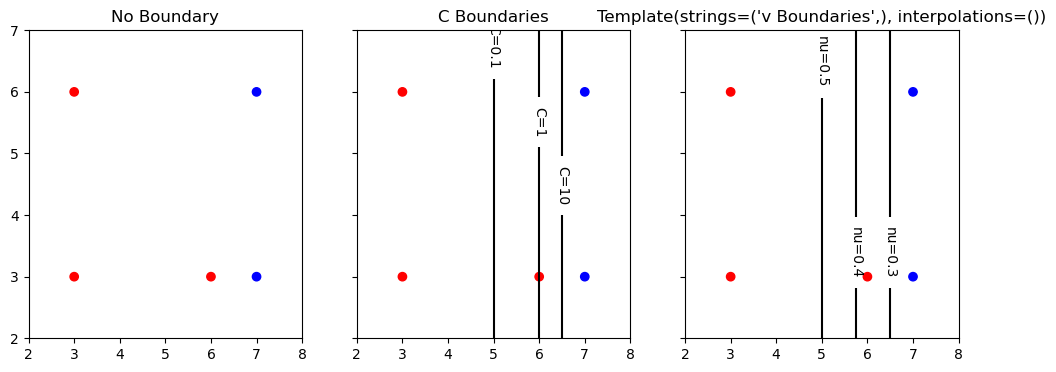

In [94]:
ftrs = np.array([[3,3],
                 [3,6],
                 [7,3],
                 [7,6],
                 [6,3]])
tgt  = np.array([0,0,1,1,0])
colors = np.array(['r', 'b'])

Cs = [.1, 1.0, 10]
nus = [.3, .4, .5]

fig, axes = plt.subplots(1,3,figsize=(12,4),
                         sharex=True, sharey=True)
for ax in axes:
    ax.scatter(ftrs[:,0], ftrs[:,1], c=colors[tgt])
ax.set_xlim(2,8); ax.set_ylim(2,7)

do_linear_svc_separators(svm.SVC,   "C",   Cs, axes[1])
do_linear_svc_separators(svm.NuSVC, "nu", nus, axes[2])

axes[0].set_title("No Boundary")
axes[1].set_title("C Boundaries")
axes[2].set_title(t"v Boundaries");


#### **bias-variance tradeoff in svc**
> how our parameters—ν in
NuSVC and C in SVC —relate to bias and variance.   
- **LARGE `C` / small `nu`**: complex model, fits training data closely → risk of **overfitting** (low bias, high variance).
- **small `C` / LARGE `nu`**: simpler model, larger margin → risk of **underfitting** (high bias, low variance).
- **validation curves** show performance peaks at intermediate values; extremes hurt generalization.

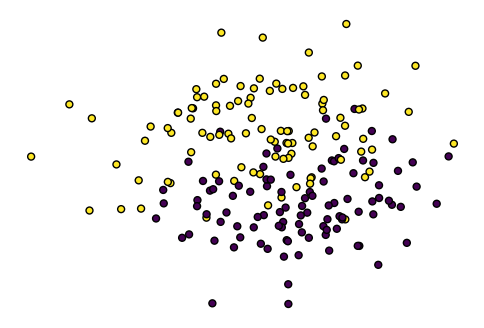

In [95]:
ftrs, tgt = datasets.make_blobs(centers=2, n_features=3, n_samples=200, 
                                center_box = (-2.0, 2.0), random_state=1099)
# note: using three features, but graphing only two dimensions

fig, ax = plt.subplots(1,1,figsize=(6,4))

ax.scatter(ftrs[:, 0], ftrs[:, 1],
           marker='o', c=tgt, s=25, edgecolor='k')

ax.axis('off');
# generally the yellow class is on top
# and the purple class is on bottom

##### effect of `ν`:

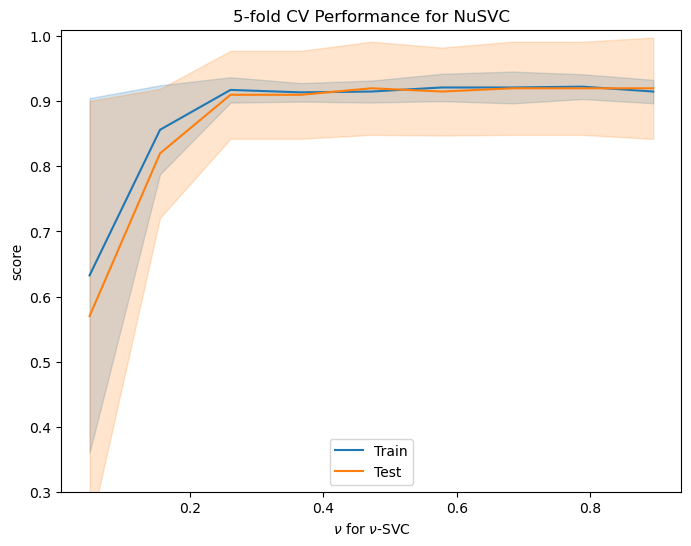

In [99]:
# # compute means and plot with error bars (most similar to tsplot)
# train_mean = np.mean(train_scores, axis=1)
# train_std = np.std(train_scores, axis=1)
# test_mean = np.mean(test_scores, axis=1)
# test_std = np.std(test_scores, axis=1)

# fig, ax = plt.subplots(1,1,figsize=(4,3))

# ax.errorbar(nus, train_mean, yerr=train_std, label='Train', capsize=5)
# ax.errorbar(nus, test_mean, yerr=test_std, label='Test', capsize=5)

# ax.set_title('5-fold CV Performance for NuSVC')
# ax.set_xlabel(r'$\nu$ for $\nu$-SVC')
# ax.set_ylim(.3, 1.01)
# ax.legend(loc='lower center')


nus = np.linspace(0.05, 1.0, 10)

tt = skms.validation_curve(svm.NuSVC(kernel='linear'),
                           ftrs, tgt,
                           param_name='nu',
                           param_range=nus,
                           cv=5)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Get train and test scores from validation_curve
train_scores, test_scores = tt

# Reshape data for seaborn lineplot (convert to long format)
# validation_curve returns shapes: train_scores = (10, 5), test_scores = (10, 5) for 10 nu values and 5 folds
n_folds = train_scores.shape[1]

# Create arrays for plotting
plot_data = []
for i, nu_val in enumerate(nus):
    for fold in range(n_folds):
        plot_data.append({'nu': nu_val, 'score': train_scores[i, fold], 'condition': 'Train'})
        plot_data.append({'nu': nu_val, 'score': test_scores[i, fold], 'condition': 'Test'})

plot_df = pd.DataFrame(plot_data)

# Use seaborn lineplot as replacement for tsplot
sns.lineplot(data=plot_df, x='nu', y='score', hue='condition', 
             errorbar='sd', estimator='mean', ax=ax)

ax.set_title('5-fold CV Performance for NuSVC')
ax.set_xlabel("\n".join([r'$\nu$ for $\nu$-SVC']))
ax.set_ylim(.3, 1.01)
ax.legend(loc='lower center')


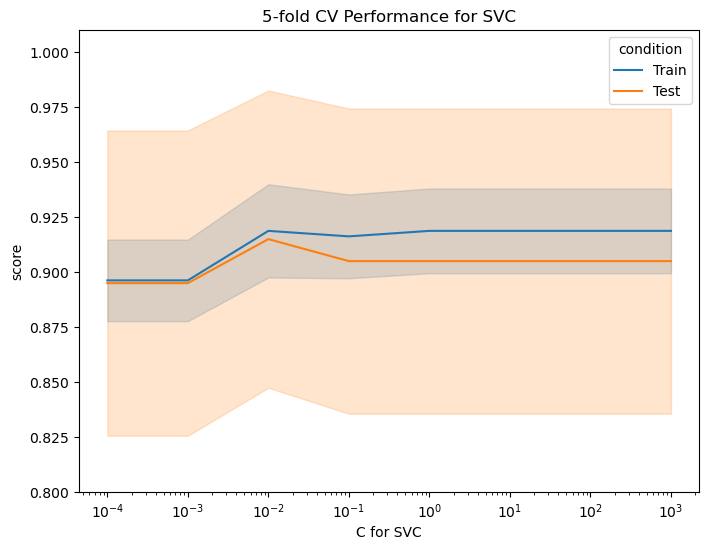

In [100]:
# cs = [0.0001, 0.001, 0.01, .1, 1.0, 10, 100, 1000]
# tt = skms.validation_curve(svm.SVC(kernel='linear'),
# ftrs, tgt,
# param_name='C',
# param_range=cs,
# cv=5)
# fig,ax = plt.subplots(1,1,figsize=(4,3))
# ax = sns.tsplot(np.array(tt).transpose(),
# time=cs,
# condition=['Train', 'Test'],
# interpolate=False)
# ax.set_title('5-fold CV Performance for SVC')
# ax.set_xlabel("\n".join([r'C for SVC']))
# ax.set_ylim(.8, 1.01)
# ax.set_xlim(.00001, 10001)
# ax.set_xscale('log')


cs = [0.0001, 0.001, 0.01, .1, 1.0, 10, 100, 1000]
tt_c = skms.validation_curve(svm.SVC(kernel='linear'),
                             ftrs, tgt,
                             param_name='C',
                             param_range=cs,
                             cv=5)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

train_scores_c, test_scores_c = tt_c

# reshape data for seaborn lineplot
plot_data_c = []
for i, c_val in enumerate(cs):
    for fold in range(train_scores_c.shape[1]):
        plot_data_c.append({'C': c_val, 'score': train_scores_c[i, fold], 'condition': 'Train'})
        plot_data_c.append({'C': c_val, 'score': test_scores_c[i, fold], 'condition': 'Test'})

plot_df_c = pd.DataFrame(plot_data_c)

sns.lineplot(data=plot_df_c, x='C', y='score', hue='condition', 
             errorbar='sd', estimator='mean', ax=ax)

ax.set_title('5-fold CV Performance for SVC')
ax.set_xlabel("\n".join([r'C for SVC']))
ax.set_ylim(.8, 1.01)
ax.set_xscale('log')

#### **wraps:**
- **Choose `C`/`nu` carefully** via cross-validation to balance margin and errors.
- SVCs are powerful for separable data but require parameter tuning to avoid over/underfitting.

---------------------------
### 3 - logistic regression:

#### **context:**
- **logistic regression is a linear classification method** that uses regression internally.
- it predicts **log-odds** of class membership, then converts to probabilities.
- two-step process:
  1. compute log-odds (related to class probabilities) via linear regression
  2. assign class with highest probability

#### odds-ratio and probs log odds and  odds:
- **odds**: `odds = P/(1-P)` (ratio of probability to its complement)
- **log-odds (logit)**: `log(P/(1-P))` - ranges from `-∞` to `+∞`
- **logistic function**: inverse of logit: `P = exp(LO)/(1+exp(LO))`


###### **why log-odds?:**
- probabilities range [0,1] → **unsuitable for linear regression**
- odds range [0,∞] → still problematic (infinite upper bound)
- **log-odds range (-∞,+∞)** → perfect for linear regression modeling
- decision boundary: when log-odds = 0 (probability = 0.5)

In [101]:
def simple_argmax(arr):
    'helper to convert np.argmax into something usable'
    return np.array(np.unravel_index(np.argmax(arr), arr.shape))

def df_names(df, idxs):
    'helper to convert number of index/column labels'
    r,c = idxs
    return df.index[r], df.columns[c]

In [102]:
base_bets = np.arange(1,12,2)
mark_bet, andy_bet = np.meshgrid(base_bets, base_bets)

mark_winnings = .1 * andy_bet + .9 * -mark_bet

df = pd.DataFrame(mark_winnings, 
                  index  =base_bets, 
                  columns=base_bets)
df.index.name = "Andy Bet"
df.columns.name = "Mark Bet"

print("Best Betting Scenario (for Mark) for These Values:")
print("(Andy, Mark):", df_names(df, simple_argmax(mark_winnings)))

display(df)

Best Betting Scenario (for Mark) for These Values:
(Andy, Mark): (np.int64(11), np.int64(1))


Mark Bet,1,3,5,7,9,11
Andy Bet,,,,,,
1,-0.8000,-2.6000,-4.4000,-6.2000,-8.0000,-9.8000
3,-0.6000,-2.4000,-4.2000,-6.0000,-7.8000,-9.6000
5,-0.4000,-2.2000,-4.0000,-5.8000,-7.6000,-9.4000
7,-0.2000,-2.0000,-3.8000,-5.6000,-7.4000,-9.2000
9,0.0000,-1.8000,-3.6000,-5.4000,-7.2000,-9.0000
11,0.2000,-1.6000,-3.4000,-5.2000,-7.0000,-8.8000


In [103]:
tail_probs = [0.0, .001, .01, .05, .10, .25, 1.0/3.0]

lwr_probs = np.array(tail_probs)
upr_probs = 1-lwr_probs[::-1]
cent_prob = np.array([.5])

probs = np.concatenate([lwr_probs, cent_prob, upr_probs])

# much better than geterr/seterr/seterr
with np.errstate(divide='ignore'):
    odds     = probs / (1-probs)
    log_odds = np.log(odds)

index=["{:4.1f}%".format(p) for p in np.round(probs,3)*100]

polo_dict = co.OrderedDict([("Prob(E)",       probs), 
                            ("Odds(E:not E)", odds), 
                            ("Log-Odds",      log_odds)])
polo_df = pd.DataFrame(polo_dict, index=index)
polo_df.index.name="Pct(%)"
polo_df

,Prob(E),Odds(E:not E),Log-Odds
Pct(%),,,
0.0%,0.0000,0.0000,-inf
0.1%,0.0010,0.0010,-6.9068
1.0%,0.0100,0.0101,-4.5951
5.0%,0.0500,0.0526,-2.9444
10.0%,0.1000,0.1111,-2.1972
25.0%,0.2500,0.3333,-1.0986
33.3%,0.3333,0.5000,-0.6931
50.0%,0.5000,1.0000,0.0000
66.7%,0.6667,2.0000,0.6931


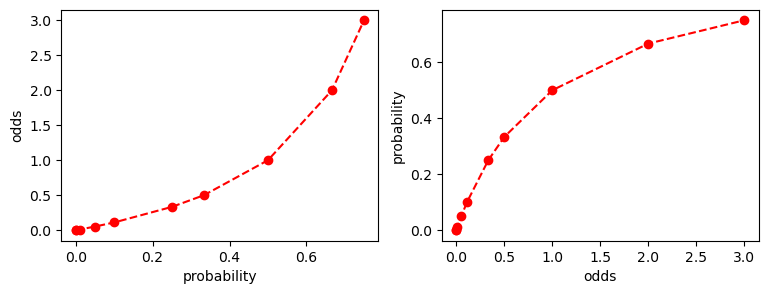

In [104]:
def helper(ax,x,y,x_name,y_name):
    ax.plot(x,y, 'r--o')
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name)

# note, we trim the values above 90% [index -5] b/c 
# the scale of the plots gets too compressed
# (huh, log-scale takes care of that! funny .....)
fig, (ax0, ax1) = plt.subplots(1,2, figsize=(9,3))
helper(ax0, probs[:-5], odds[:-5], 'probability', 'odds')
helper(ax1, odds[:-5], probs[:-5], 'odds', 'probability')

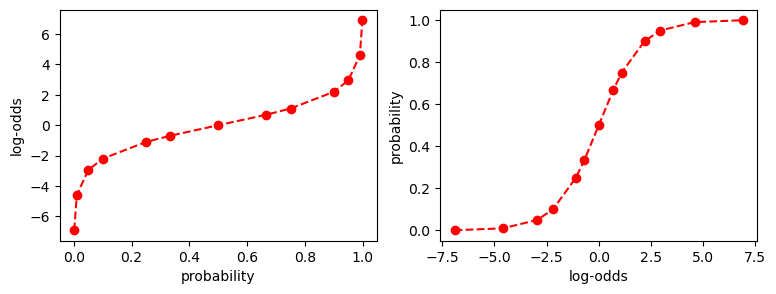

In [105]:
fig, (ax0, ax1) = plt.subplots(1,2, figsize=(9,3))
helper(ax0, probs, log_odds, 'probability', 'log-odds')
helper(ax1, log_odds, probs, 'log-odds', 'probability')

In [106]:
pd.DataFrame([polo_df.min(axis=0),
              polo_df.max(axis=0)], index=['min', 'max']).T

,min,max
Prob(E),0.0000,1.0000
Odds(E:not E),0.0000,inf
Log-Odds,-inf,inf


In [107]:
def logit(probs):
    odds = probs / (1-probs)
    log_odds = np.log(odds)
    return log_odds

#### **`scikit-learn`**
`sklearn` for logistic regression are smart step methods: from a starting point, make some adjustments, and
repeat as necessary until the answer is good enough. `SGD` is short for **Stochastic Gradient Descent**
and it is one way of performing smart steps. it makes its adjustments by looking at the
errors in the current guess and using those to lower the error of the next guess


> because of its internal use of randomness, every run may result in a different answer.
With enough data and small enough error tolerance, SGDClassifier should reach, or
converge to, similar answers on different runs
> `LogisticRegression` with `method='saga'` - allows us to use a full multiclass model instead of wrapping a binary classification with a
one-versus-rest.

1. **`LogisticRegression`** (with `solver='saga'` for multiclass)
2. **`SGDClassifier(loss='log')`** (stochastic gradient descent version)
- both include regularization by default


#### **important caveat: perfect separation problem**
- when classes are **perfectly separable**, logistic regression has infinite possible solutions
- some implementations (like statsmodels' `Logit`) fail with "perfect separation detected" error
- **in practice**: rarely occurs with real-world data; sklearn's implementations handle it via regularization


#### **decision rule**
- If `log-odds > 0` → predict class (probability > 0.5)
- If `log-odds < 0` → predict other class
- Boundary at `log-odds = 0` corresponds to `∑ w_f × x_f = 0`


#### **wraps:**
- logistic regression = **linear regression predicting log-odds**
- uses **logit transform** to map probabilities to unbounded scale
- despite name, primarily used for **classification** (not regression)

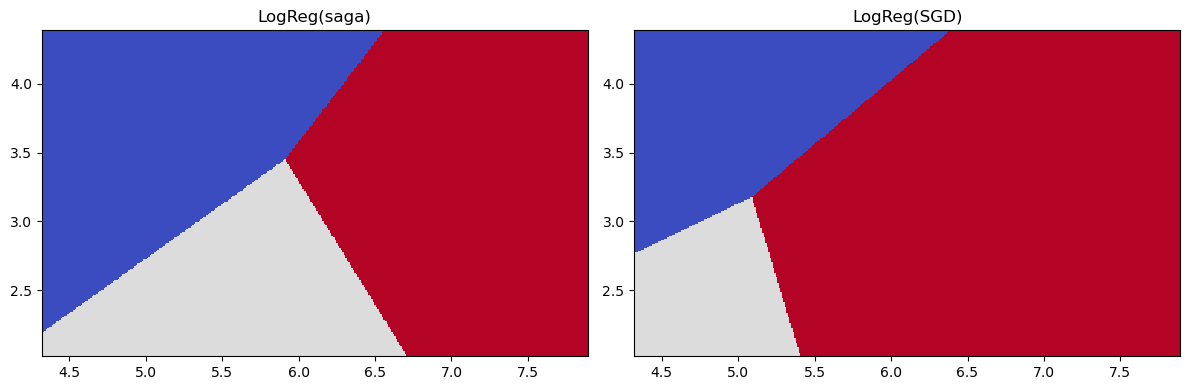

In [109]:
# Both options come with "regularization" turned ON
# we'll ignore that for now, but see Chapter 9 for more details
LogReg = linear_model.LogisticRegression
SGD = linear_model.SGDClassifier

logreg_classifiers = {'LogReg(saga)': LogReg(solver='saga', max_iter=1000), 
                      'LogReg(SGD)' : SGD(loss='perceptron', max_iter=1000)}
fig, axes = plt.subplots(1,2,figsize=(12,4))
axes = axes.flat

for (name, mod), ax in zip(logreg_classifiers.items(), axes):
    plot_boundary(ax, iris.data, iris.target, mod, [0,1])
    ax.set_title(name)
plt.tight_layout()

##### space oddity:
if all the data falls nicely into two clusters, then there is an infinite number of lines we can draw between the clusters. Logistic regression doesn’t have a built-in answer to picking one of these infinite alternatives. Trying to solve a
perfectly separable classification problem with logistic regression may lead to problematic
answers. fortunately, 
1. those problems are more serious for statisticians than they are for
us using logistic regression as a black-box prediction method and
2. for practical purposes in interesting problems, we will never have perfectly separable data.

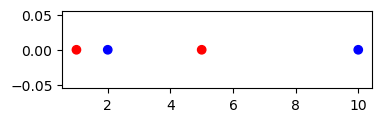

In [110]:
fig, ax = plt.subplots(1,1,figsize=(4,1))

x = np.array([1,2,5,10]).reshape(-1, 1)
y = ['red', 'blue', 'red', 'blue']
ax.scatter(x,np.zeros_like(x), c=y);

a typical scenario: the two classes are intertwined. we’ll use a non-sklearn
method to perform logistic regression. this method is meant to expose our issue clearly

In [111]:
# note:  different import source
import statsmodels.api as sm

x = np.c_[x, np.ones_like(x)] # +1 trick
tgt = (np.array(y) == 'red')

# sm.Logit is statsmodels name for logistic regression
# Logit is very, very unhappy trying to deal with a perfectly 
#       separable example.  so, there are many weird arguments.
#       and it still seems to fail.
# FIXME.  I want just a simple example that recovers the target
#         function.
#(sm.Logit(tgt, x)
#   .fit(method='newton', skip_hessian=True, 
#        full_output=False, warn_convergence=False)
#   .predict(x))  # training predictions

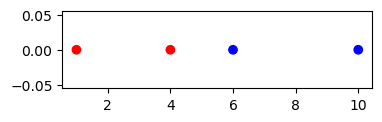

In [112]:
fig, ax = plt.subplots(1,1,figsize=(4,1))

x = np.array([1,4,6,10]).reshape(-1, 1)
y = ['red', 'red', 'blue', 'blue']
ax.scatter(x, np.zeros_like(x), c=y);

In [115]:
import numpy as np
import statsmodels.api as sm

def run_logit_example(x_vals, y, example_name):
    """Helper function to run logistic regression example."""
    print(f"\n--- {example_name} ---")
    
    # Add constant
    x = sm.add_constant(x_vals)
    tgt = (np.array(y) == 'red')
    
    # Try different methods
    methods = ['newton', 'bfgs', 'nm']  # nm = Nelder-Mead
    
    for method in methods:
        try:
            model = sm.Logit(tgt, x)
            result = model.fit(method=method, maxiter=100, disp=0)
            predictions = result.predict(x)
            print(f"Method: {method}, Predictions: {predictions}")
            return  # Success, exit function
        except Exception as e:
            if method == methods[-1]:  # Last method failed
                print(f"All methods failed. Perfect separation detected.")
                print(f"Last error: {e}")

# Example 1: Non-perfect separation
x_vals1 = np.array([1, 2, 5, 10]).reshape(-1, 1)
y1 = ['red', 'blue', 'red', 'blue']
run_logit_example(x_vals1, y1, "Example 1")

# Example 2: Perfect separation
x_vals2 = np.array([1, 4, 6, 10]).reshape(-1, 1)
y2 = ['red', 'red', 'blue', 'blue']
run_logit_example(x_vals2, y2, "Example 2")


--- Example 1 ---
Method: newton, Predictions: [0.7183 0.6583 0.4537 0.1697]

--- Example 2 ---
Method: newton, Predictions: [1. 1. 0. 0.]


what happens with a
seemingly minor change to the data.

In [116]:
x = np.c_[x, np.ones_like(x)] # +1 trick
tgt = (np.array(y) == 'red')
try:
    (sm.Logit(tgt, x, method='newton')
       .fit()
       .predict(x)) # in-sample predictions
except Exception as e:
    print(e)

         Current function value: 0.000000
         Iterations: 35
Singular matrix


`Logit` refuses to solve the problem for us. it warns us that there was perfect
separation between the classes and there are no results to use. it seems like drawing the
perfect line would be easy - it isn’t. 

the problem is that there is an infinite number of lines
that we could draw and our old-school logistic regression doesn’t have a built-in way to
pick between them. in turn, some methods don’t do well with that uncertainty and can
give very bad answers - `Logit` stops with a fail

--------------------------------
## 4 - discriminant analysis(da):

> can tell subtle differences in flavors
> - DA methods are **statistical classifiers** that model relationships between features and target classes.
> - Based on **covariance** (measure of how features vary together) and different assumptions about feature relationships.

#### features:

DA methods are very interesting for at least three reasons:
1. they have a wonderfully clear mathematical connection with Naive Bayes on
continuous features (Gaussian Naive Bayes, GNB).
2. like GNB, discriminant analysis methods model the features and the target together.
3. DA methods arise from particularly simple—or perhaps mathematically
convenient—assumptions about the data. The different DA methods make slightly
different assumptions.

### methods & their assumptions**
four main DA methods differ in their **covariance matrix** assumptions:

1. **QDA (duadratic discriminant analysis)**:
   - **assumption**: each class has its own **full covariance matrix** (任意).
   - most flexible, allows curved decision boundaries.

2. **LDA (linear discriminant analysis)**:
   - **assumption**: all classes share the **same full covariance matrix**.
   - linear decision boundaries, fewer parameters to estimate.

3. **GNB (gaussian naive bayes)**:
   - **Assumption**: Each class has its own **diagonal covariance matrix** (covariances = 0).
   - features assumed independent within each class (hence "Naive").

4. **DLDA (diagonal LDA)**:
   - **Assumption**: all classes share the **same diagonal covariance matrix** (covariances = 0).
   - combines LDA's shared matrix with GNB's diagonal constraint.

#### **understanding covariance**
- **variance**: `Var(X) = 1/n Σ (x - mean)²` (average squared deviation from mean).
- **Covariance**: `Cov(X,Y) = 1/n Σ (x - mean_X)(y - mean_Y)`.
  - positive: X and Y tend to increase together.
  - negative: One increases while the other decreases.
  - Zero: No linear relationship.
- **Interpretation**: Average signed area of rectangles defined by data point pairs.

#### **covariance matrix**
- Square matrix showing covariances between all feature pairs.
- Diagonal entries are variances (Cov(X,X) = Var(X)).
- Symmetric: Cov(X,Y) = Cov(Y,X).
- **Diagonal matrix**: All off-diagonal entries = 0 (features uncorrelated).

#### **MISC**
- **trade-off**: more assumptions → simpler models, fewer parameters, less risk of overfitting.
- **LDA often a sweet spot**: shared covariance reduces parameters while maintaining flexibility.
- **decision boundaries**: QDA/GNB can be curved; LDA/DLDA produce linear boundaries.
- **model selection**: try multiple DA methods via cross-validation; simplest adequate model preferred (Occam's razor).

#### **`sklearn`**
- a list of these:`QuadraticDiscriminantAnalysis()`, `LinearDiscriminantAnalysis()`, `GaussianNB()`
- DLDA may require custom implementation (not directly in sklearn).
- confusion matrices and boundary plots help compare methods.

#### **mathematical connection**
- DA methods model **joint distribution** of features and target (like naive bayes).
- differ in how they parameterize the covariance structure of feature distributions.

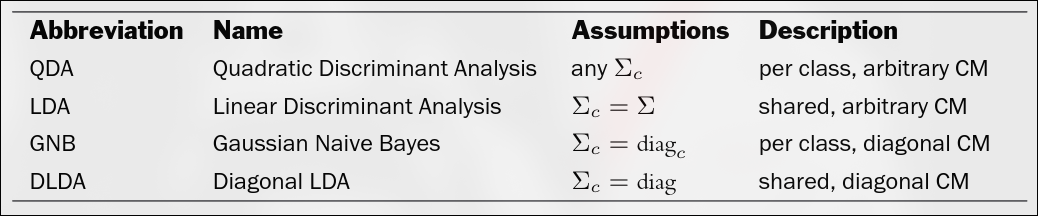

#### performing da:
> do simple train-test split and
look at the confusion matrices from each of the four methods.

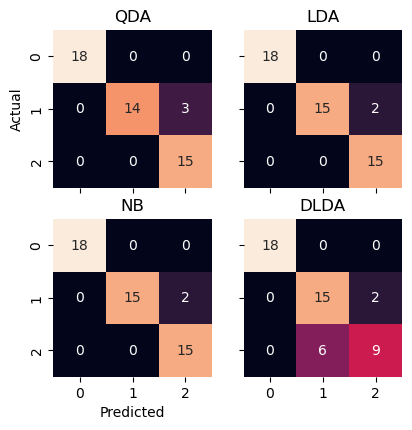

In [61]:
qda  = discriminant_analysis.QuadraticDiscriminantAnalysis()
lda  = discriminant_analysis.LinearDiscriminantAnalysis()
nb   = naive_bayes.GaussianNB()
dlda = DLDA() # from mlwpy.py

da_methods = [qda, lda, nb, dlda]
names = ["QDA", "LDA", "NB", "DLDA"]
    
fig, axes = plt.subplots(2,2, figsize=(4.5, 4.5),
                         sharex=True, sharey = True)
for ax, model, name in zip(axes.flat, da_methods, names):
    preds = (model.fit(iris_train_ftrs, iris_train_tgt)
                  .predict(iris_test_ftrs))
    cm = metrics.confusion_matrix(iris_test_tgt, preds)
    sns.heatmap(cm, annot=True, cbar=False, ax=ax)
    ax.set_title(name)

axes[0,0].set_ylabel('Actual')
axes[1,0].set_xlabel('Predicted');

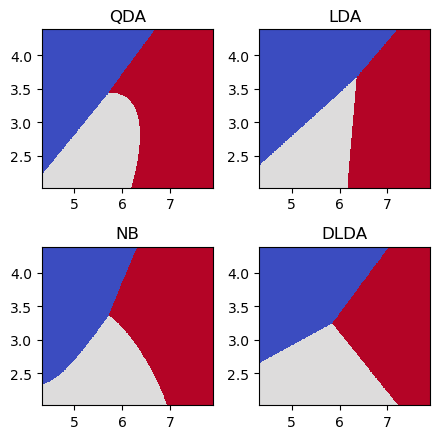

In [62]:
fig, axes = plt.subplots(2,2,figsize=(4.5, 4.5))
axes = axes.flat

for model, ax, name in zip(da_methods, axes, names):
    # plot boundary only uses the specified (two) dimensions to predict
    plot_boundary(ax, iris.data, iris.target, model, [0,1])
    ax.set_title(name)
plt.tight_layout()
     

both QDA and GNB have nonlinear boundaries—they curve a bit. LDA and DLDA
both have linear borders between the classes.

### **Classification Methods Comparison**

#### **Linearity vs. Nonlinearity**
- **Linear classifiers**: create straight-line (or flat-plane) boundaries.
  - **examples**: Linear SVC, Logistic Regression, LDA, DLDA.
  - Best for data separable by simple linear patterns.
- **Nonlinear classifiers**: Create curved or complex boundaries.
  - **examples**: k-NN, Decision Trees (deep), QDA, GNB.
  - Can capture more complex patterns but risk overfitting.

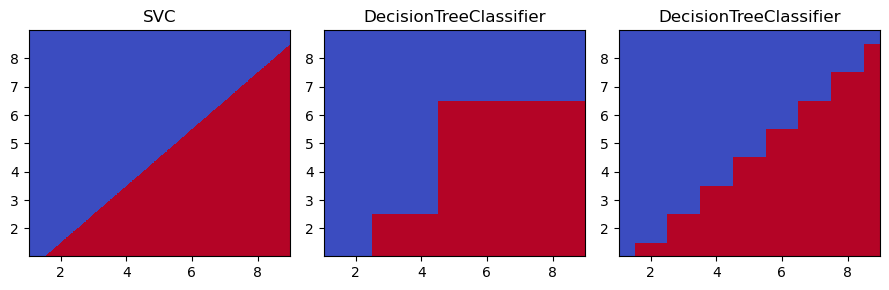

In [63]:
ftrs = np.mgrid[1:10, 1:10].T.reshape(-1,2)
tgt  = ftrs[:,0] > ftrs[:,1]

fig, axes = plt.subplots(1,3,figsize=(9,3))
axes = axes.flat

svc = svm.SVC(kernel='linear')
dt_shallow  = tree.DecisionTreeClassifier(max_depth=3)
dt_deep     = tree.DecisionTreeClassifier()
models = [svc, dt_shallow, dt_deep]

for model, ax in zip(models, axes):
    # plot boundary only uses the specified (two) dimensions to predict
    plot_boundary(ax, ftrs, tgt, model, [0,1])
    ax.set_title(get_model_name(model))
plt.tight_layout()

#### **Flexibility & Assumptions Spectrum**
**From most flexible (fewest assumptions) to most constrained**:

1. **Decision Trees (DTs)**:
   - **Assumptions**: Minimal; can approximate any pattern.
   - **Risk**: High variance, prone to overfitting (especially unconstrained).
   - **Control**: Limit depth, require minimum samples per leaf.

2. **Support Vector Classifiers (SVCs)**:
   - **Assumptions**: Minimal; seeks maximum margin separator.
   - **Flexibility**: Can be made nonlinear with kernels (Chapter 13).
   - **Regularization**: Controlled by `C` (trade-off margin vs. errors).

3. **Logistic Regression**:
   - **Assumption**: Linear relationship between features and log-odds of target.
   - **Modeling**: Probability of target **given** inputs (ignores base target rates).
   - **Issue**: Fails with perfectly separable data (infinite solutions).

4. **Discriminant Analysis (DA)**:
   - **Assumption**: Models feature distribution **given** target class.
   - **Also models**: Base probabilities (priors) of target classes.
   - **Family**: QDA (class-specific full covariances), LDA (shared full covariance), GNB (class-specific diagonal covariance), DLDA (shared diagonal covariance).

#### **formulae**
- **Log-odds**: `LO(x) = log(P(x)/(1-P(x))) = Σ w_f * x_f`
- **Logistic function**: `P(x) = exp(LO(x))/(1+exp(LO(x)))`
- **Covariance**: `Cov(X,Y) = 1/n Σ (x_i - mean_X)(y_i - mean_Y)`
- **Decision boundary**: For linear classifiers, where `Σ w_f * x_f = 0` (log-odds=0).

----------
## DIGITS:
> built-in dataset from sklearn  
> the data represents simple images of handwritten digits
>
> the dataset faces in two directions/forms: one (`digits.images`) is appropriate for display
purposes; the other (`digits.data`) is appropriate for use in learning.  that form is a flattened row of the information in the square 64 × 64 images.

In [64]:
digits = datasets.load_digits()

Shape: (8, 8)


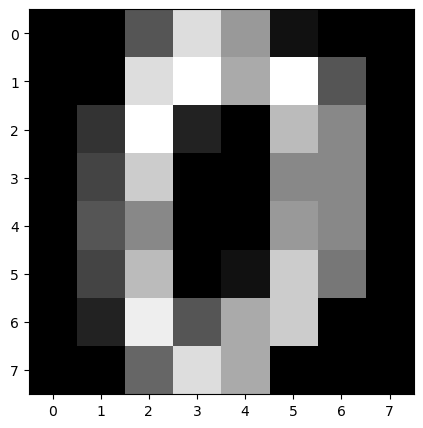

In [66]:
print("Shape:", digits.images[0].shape)
plt.figure(figsize=(5,5))
plt.imshow(digits.images[0], cmap='gray'); 

In [67]:
digits.target[0]

np.int64(0)

In [72]:
classifier_parade = \
    {'LogReg(1)' : linear_model.LogisticRegression(max_iter=10000),
     'LogReg(2)' : linear_model.SGDClassifier(loss='log_loss',
                                              max_iter=10000),

     'QDA' : discriminant_analysis.QuadraticDiscriminantAnalysis(reg_param=0.5), # regularization
     'LDA' : discriminant_analysis.LinearDiscriminantAnalysis(),
     'GNB' : naive_bayes.GaussianNB(),

     'SVC(1)' : svm.SVC(kernel="linear"),
     'SVC(2)' : svm.LinearSVC(),

     'DTC'    : tree.DecisionTreeClassifier(),
     '5NN-C'  : neighbors.KNeighborsClassifier(),
     '10NN-C' : neighbors.KNeighborsClassifier(n_neighbors=10)}

baseline = dummy.DummyClassifier(strategy="uniform")

base_score = skms.cross_val_score(baseline, digits.data, digits.target==1, 
                                  cv=10, scoring='average_precision', n_jobs=-1)

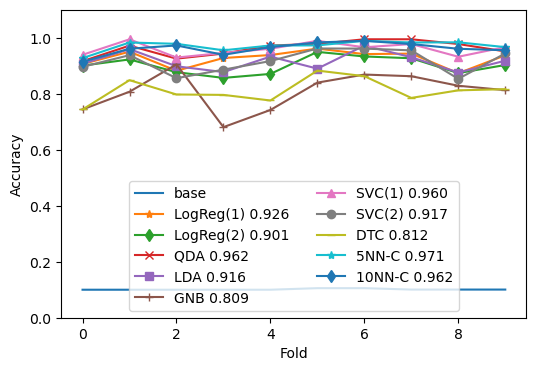

In [73]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(base_score, label='base')
for name, model in classifier_parade.items():    
    cv_scores = skms.cross_val_score(model, 
                                     digits.data, digits.target, 
                                     cv=10, 
                                     scoring='f1_macro', 
                                     n_jobs=-1) # all CPUs
    my_lbl = "{} {:.3f}".format(name, cv_scores.mean())
    ax.plot(cv_scores, label=my_lbl, marker=next(markers))
ax.set_ylim(0.0, 1.1)
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.legend(loc='lower center', ncol=2);

### END